# Network Analysis

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
#Create a social network
G = nx.Graph()

edges = [
    #Core gang
    ("Charlie", "Dee"),
    ("Charlie", "Mac"),
    ("Charlie", "Frank"),
    ("Charlie", "Dennis"),
    ("Dee", "Dennis"),
    ("Dee", "Frank"),
    ("Dennis", "Frank"),
    ("Dennis", "Mac"),
    ("Mac", "Frank"),

    #Original list
    ("Dee", "Bill Ponderosa"),
    ("Dennis", "Maureen Ponderosa"),
    ("Bill Ponderosa", "Maureen Ponderosa"),
    ("Frank", "Cricket"),
    ("Dennis", "Cricket"),
    ("Frank", "Artemis"),
    ("Artemis", "Dee"),
    ("Charlie", "The Waitress"),
    ("Dennis", "The Waitress"),
    ("Charlie", "Uncle Jack"),
    ("Charlie", "Bonnie Kelly"),
    ("Frank", "Bonnie Kelly"),
    ("Mac", "Country Mac"),
    ("Mac", "Mrs. Mac"),
    ("Frank", "Gail the Snail"),
    ("Dennis", "Gail the Snail"),
    ("Dee", "Gail the Snail"),

    #The Waiter and Guigino's night
    ("The Waiter", "Dee"),
    ("The Waiter", "Charlie"),
    ("The Waiter", "Dennis"),
    ("The Waiter", "Mac"),
    ("The Waiter", "Frank"),

    #Roxy 
    ("Roxy", "Frank"),
    ("Roxy", "Dee"),

    #Ben the Soldier 
    ("Ben the Soldier", "Dee"),
    ("Ben the Soldier", "Artemis"),

    #Under the bridge crew
    ("Z", "Frank"),
    ("Z", "Charlie"),
    ("Duncan", "Z"),
    ("Duncan", "Frank"),

    #Reynolds family
    ("Barbara Reynolds", "Frank"),
    ("Barbara Reynolds", "Dennis"),
    ("Barbara Reynolds", "Dee"),
    ("Pop-Pop Landgraf", "Barbara Reynolds"),

    #Mac family
    ("Luther McDonald", "Mac"),
    ("Mrs. Mac", "Luther McDonald"),

    #Brad Fisher
    ("Brad Fisher", "The Waitress"),
    ("Brad Fisher", "Dee"),
    ("Brad Fisher", "Charlie"),

    #Carmen 
    ("Carmen", "Mac"),
    ("Carmen", "Dee"),

    #Da Maniac
    ("Da Maniac", "Mac"),
    ("Da Maniac", "Dennis"),
    ("Da Maniac", "Dee"),
    ("Da Maniac", "Charlie"),
    ("Da Maniac", "Frank"),

    #McPoyles
    ("Liam McPoyle", "Ryan McPoyle"),
    ("Liam McPoyle", "Margaret McPoyle"),
    ("Ryan McPoyle", "Margaret McPoyle"),
    ("Liam McPoyle", "Charlie"),
    ("Liam McPoyle", "Dennis"),
    ("Liam McPoyle", "Dee"),
    ("Ryan McPoyle", "Charlie"),
    ("Ryan McPoyle", "Mac"),
    ("Ryan McPoyle", "Dennis"),
    ("Margaret McPoyle", "Dennis"),
    
]

G.add_edges_from(edges)

Nodes: 29
Edges: 65


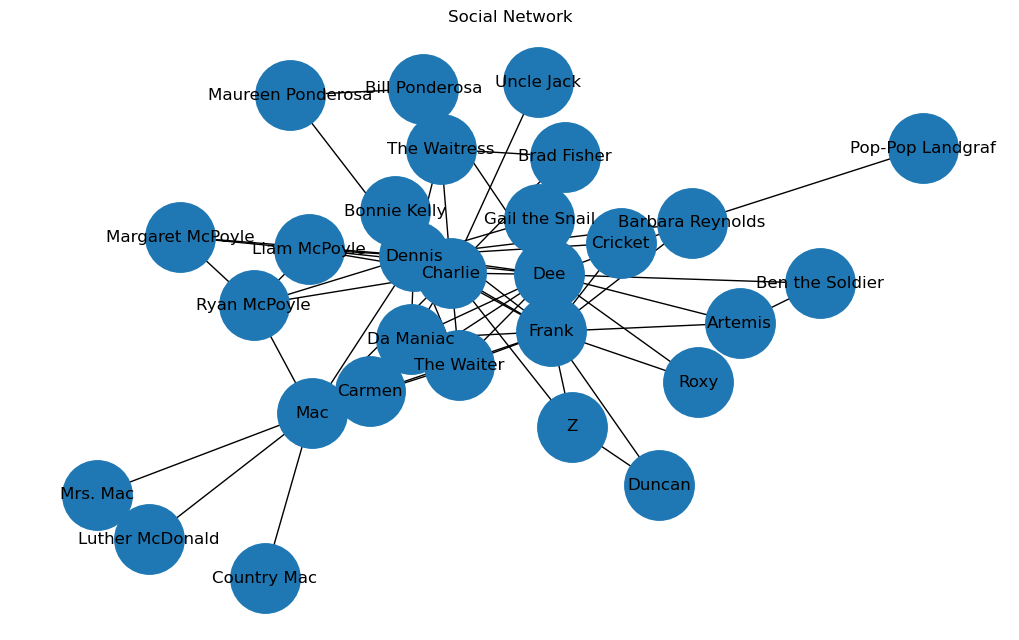

In [4]:
#Plot the network
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=1663)  #Nodes placed using the spring layout algorithm
nx.draw(G, pos, with_labels=True, node_size=2500)
plt.title('Social Network')
plt.show()

In [111]:
# Calculate some basic network metrics
print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())
print("Average Clustering Coefficient:", nx.average_clustering(G))
print("Degree Centrality:", nx.degree_centrality(G))

Number of Nodes: 14
Number of Edges: 23
Average Clustering Coefficient: 0.47891156462585033
Degree Centrality: {'Charlie': 0.5384615384615385, 'Dee': 0.46153846153846156, 'Mac': 0.23076923076923078, 'Frank': 0.6153846153846154, 'Dennis': 0.5384615384615385, 'Bill Ponderosa': 0.15384615384615385, 'Cricket': 0.07692307692307693, 'Artemis': 0.15384615384615385, 'The Waitress': 0.15384615384615385, 'Uncle Jack': 0.07692307692307693, 'Gail the Snail': 0.23076923076923078, 'Bonnie Kelly': 0.15384615384615385, 'Country Mac': 0.07692307692307693, 'Maureen Ponderosa': 0.07692307692307693}


In [5]:
shortest_path = nx.shortest_path(G, 'Ben the Soldier', 'Country Mac')
print("Shortest Path:", shortest_path)
print(f'It takes {len(shortest_path)} hops to get from Cricket to Country Mac')
print('\n')

shortest_path = nx.shortest_path(G, 'Cricket', 'Uncle Jack')
print("Shortest Path:", shortest_path)
print(f'It takes {len(shortest_path)} hops to get from Cricket to Maureen Ponderosa')
print('\n')

shortest_path = nx.shortest_path(G, 'Charlie', 'Country Mac')
print("Shortest Path:", shortest_path)
print(f'It takes {len(shortest_path)} hops to get from Charlie to Country Mac')

Shortest Path: ['Ben the Soldier', 'Dee', 'Charlie', 'Mac', 'Country Mac']
It takes 5 hops to get from Cricket to Country Mac


Shortest Path: ['Cricket', 'Frank', 'Charlie', 'Uncle Jack']
It takes 4 hops to get from Cricket to Maureen Ponderosa


Shortest Path: ['Charlie', 'Mac', 'Country Mac']
It takes 3 hops to get from Charlie to Country Mac


In [6]:
#Community Detection
communities = nx.algorithms.community.greedy_modularity_communities(G)
print("Communities:", communities)

Communities: [frozenset({'Roxy', 'Artemis', 'Maureen Ponderosa', 'Ben the Soldier', 'Dee', 'Bill Ponderosa', 'Gail the Snail'}), frozenset({'Pop-Pop Landgraf', 'Frank', 'Barbara Reynolds', 'Cricket', 'Bonnie Kelly', 'Duncan', 'Z'}), frozenset({'Da Maniac', 'Mrs. Mac', 'Carmen', 'Mac', 'Country Mac', 'Luther McDonald'}), frozenset({'Uncle Jack', 'Charlie', 'The Waiter', 'Brad Fisher', 'The Waitress'}), frozenset({'Liam McPoyle', 'Margaret McPoyle', 'Ryan McPoyle', 'Dennis'})]


In [7]:
import networkx as nx

G = nx.Graph()
G.add_edges_from(edges)

deg = dict(G.degree())
btw = nx.betweenness_centrality(G, k=min(500, G.number_of_nodes()), normalized=True, seed=42)  # approx if big
pr  = nx.pagerank(G)

def top_k(d, k=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:k]

print("Top Degree:", top_k(deg))
print("Top Betweenness (bridges):", top_k(btw))
print("Top PageRank:", top_k(pr))

Top Degree: [('Dee', 14), ('Frank', 14), ('Dennis', 14), ('Charlie', 13), ('Mac', 10), ('The Waiter', 5), ('Da Maniac', 5), ('Liam McPoyle', 5), ('Ryan McPoyle', 5), ('Barbara Reynolds', 4)]
Top Betweenness (bridges): [('Frank', 0.2432476694381456), ('Dee', 0.24296422272612753), ('Mac', 0.22755731922398587), ('Dennis', 0.22521415973796924), ('Charlie', 0.19319098009574204), ('Barbara Reynolds', 0.07142857142857142), ('Liam McPoyle', 0.013227513227513227), ('Ryan McPoyle', 0.013007054673721338), ('Artemis', 0.006802721088435373), ('Bill Ponderosa', 0.005952380952380952)]
Top PageRank: [('Dee', 0.09935636825971149), ('Frank', 0.09877262313986192), ('Dennis', 0.09615656662633788), ('Charlie', 0.0909538031424363), ('Mac', 0.07562277220043498), ('Ryan McPoyle', 0.036026468644759245), ('Liam McPoyle', 0.0356884685371244), ('The Waiter', 0.03541517594766442), ('Da Maniac', 0.03541517594766442), ('Barbara Reynolds', 0.03348511166465231)]


In [8]:
triangles = nx.triangles(G)  # triangles per node
clust = nx.clustering(G)

print("Top triangle counts:", sorted(triangles.items(), key=lambda x: x[1], reverse=True)[:5])
print("Top clustering coefficient:", sorted(clust.items(), key=lambda x: x[1], reverse=True)[:5])

print("Total triangles in graph:", sum(triangles.values()) // 3)

Top triangle counts: [('Dennis', 26), ('Charlie', 23), ('Frank', 23), ('Dee', 19), ('Mac', 12)]
Top clustering coefficient: [('Cricket', 1.0), ('Bonnie Kelly', 1.0), ('Mrs. Mac', 1.0), ('Gail the Snail', 1.0), ('Roxy', 1.0)]
Total triangles in graph: 53


In [9]:
bridges = list(nx.bridges(G))
arts = list(nx.articulation_points(G))

print("Articulation points (remove them, network splits):", arts)
print("Bridge edges (remove them, network splits):", bridges)

Articulation points (remove them, network splits): ['Mac', 'Barbara Reynolds', 'Charlie']
Bridge edges (remove them, network splits): [('Charlie', 'Uncle Jack'), ('Mac', 'Country Mac'), ('Barbara Reynolds', 'Pop-Pop Landgraf')]
